# 95 — Match nodal detections to Geode metadata using time + nodal source-position estimates

Refactored matching notebook using high-pass nodal energy source-position estimates, candidate scoring, clock-offset diagnostics, and off-end shot tests.

In [38]:

from pathlib import Path
import json
import sqlite3
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from obspy import read, UTCDateTime

import sys
LIB = Path('../lib').resolve()
if LIB.exists() and str(LIB) not in sys.path:
    sys.path.append(str(LIB))

try:
    from segy_tools.gather import plot_wiggle_gather_from_stream
    HAVE_SEGY_TOOLS = True
except Exception as e:
    HAVE_SEGY_TOOLS = False
    print('segy_tools plotting unavailable:', e)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


segy_tools plotting unavailable: No module named 'segy_tools'


## 1. Configuration

In [39]:

PROJECT_ROOT = Path('/Volumes/tachyon/LBSSP_DATA')
CATALOG_DB = PROJECT_ROOT / 'catalog' / 'lbssp_shot_catalog.sqlite'
OUTPUT_DIR = PROJECT_ROOT / 'catalog' / 'match_review'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_TIMEWINDOW_LABEL = 'T1_N2_Refraction1m'
TARGET_GEODE_SURVEY = 'T1_1m_refraction'
TARGET_LINE = 'T1'
MAX_EVENTS_TO_REVIEW = 100   # set None for all selected events

# Day-3 note: Geode/laptop clock was 11.5 s ahead of UTC at start of T1 1-m refraction.
# Corrected Geode time = recorded Geode file time - GEODE_CLOCK_AHEAD_S.
GEODE_CLOCK_AHEAD_S = 11.5

# Do not force one clock correction yet. Explore alternatives.
#GEODE_OFFSET_HYPOTHESES_S = [0.0, -11.5, 11.5, -23.0, 23.0]

# Allow nodal detections before/after the candidate Geode time. Geode file time may be first trigger in a stack; nodal events may occur after this.
TIME_BEFORE_S = 90.0
TIME_AFTER_S = 180.0

# Candidate score = abs(time residual)/TIME_SCALE_S + abs(source-x residual)/SOURCE_X_SCALE_M.
TIME_SCALE_S = 120.0
SOURCE_X_SCALE_M = 5.0

SOURCE_COMPONENT = 'Z'
SOURCE_HP_FREQ_HZ = 25.0
SOURCE_HP_CORNERS = 4
ENERGY_TMIN_S = 0.0
ENERGY_TMAX_S = None       # None = full gather window
TOP_N = 3
TOP_FRACTION_OF_MAX = 0.10

PLOT_TMIN_S = 0.0
PLOT_TMAX_S = 0.5


## 2. Database helpers

In [40]:

def connect_catalog(db_path=CATALOG_DB):
    db_path = Path(db_path)
    if not db_path.exists():
        raise FileNotFoundError(db_path)
    conn = sqlite3.connect(db_path)
    conn.execute('PRAGMA foreign_keys = ON;')
    conn.execute('PRAGMA busy_timeout = 30000;')
    return conn


def table_exists(conn, table):
    return conn.execute("SELECT name FROM sqlite_master WHERE type='table' AND name=?", (table,)).fetchone() is not None


def load_table(conn, table):
    if not table_exists(conn, table):
        print(f'Missing table: {table}')
        return pd.DataFrame()
    return pd.read_sql(f'SELECT * FROM {table}', conn)

conn = connect_catalog()


## 3. Load and normalize catalog tables

In [41]:

shot_events = load_table(conn, 'shot_events')
gather_files = load_table(conn, 'shot_gather_files')
trace_index = load_table(conn, 'trace_index')
picks = load_table(conn, 'picks')
receiver_geometry = load_table(conn, 'receiver_geometry')

print('shot_events:', len(shot_events))
print('shot_gather_files:', len(gather_files))
print('trace_index:', len(trace_index))
print('picks:', len(picks))
print('receiver_geometry:', len(receiver_geometry))


def ensure_columns(df, defaults):
    df = df.copy()
    for c, v in defaults.items():
        if c not in df.columns:
            df[c] = v
    return df

shot_events = ensure_columns(shot_events, {
    'event_id': None, 'instrument_system': None, 'line': None, 'timewindow_label': None,
    'shot_time_utc': None, 'detection_time_utc': None, 'source_x_m': np.nan,
    'source_type': None, 'operator': None, 'plate_type': None, 'n_blows': np.nan,
    'file_no': None, 'survey': None, 'survey_type': None, 'metadata_match_status': None,
    'matched_metadata_event_id': None,
})


def to_utc_datetime(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return pd.NaT
    try:
        return pd.to_datetime(value, utc=True)
    except Exception:
        return pd.NaT

shot_events['shot_time_dt'] = shot_events['shot_time_utc'].apply(to_utc_datetime)
shot_events['detection_time_dt'] = shot_events['detection_time_utc'].apply(to_utc_datetime)
shot_events['event_time_dt'] = shot_events['detection_time_dt'].where(
    shot_events['instrument_system'].astype(str).str.lower().eq('nodal'),
    shot_events['shot_time_dt']
)
shot_events['event_time_dt'] = shot_events['event_time_dt'].fillna(shot_events['shot_time_dt']).fillna(shot_events['detection_time_dt'])

nodal_events = shot_events[shot_events['instrument_system'].astype(str).str.lower().eq('nodal')].copy()
geode_events = shot_events[~shot_events['instrument_system'].astype(str).str.lower().eq('nodal')].copy()

print('nodal_events:', len(nodal_events))
print('geode_events:', len(geode_events))
display(nodal_events[['event_id','line','timewindow_label','event_time_dt','source_x_m','source_type']].head())
display(geode_events[['event_id','survey','line','shot_time_dt','source_x_m','source_type','file_no','n_blows']].head())


shot_events: 3752
shot_gather_files: 3610
trace_index: 344514
picks: 787402
receiver_geometry: 7530
nodal_events: 3425
geode_events: 327


,event_id,line,timewindow_label,event_time_dt,source_x_m,source_type
327,T1_N1_Streamer_T1_N1_E00001,T1,T1_N1_Streamer,2026-05-16 17:13:01.890000+00:00,NaN,None
328,T1_N1_Streamer_T1_N1_E00002,T1,T1_N1_Streamer,2026-05-16 17:13:14.824000+00:00,NaN,None
329,T1_N1_Streamer_T1_N1_E00003,T1,T1_N1_Streamer,2026-05-16 17:13:28.030000+00:00,NaN,None
330,T1_N1_Streamer_T1_N1_E00004,T1,T1_N1_Streamer,2026-05-16 17:13:30.858000+00:00,NaN,None
331,T1_N1_Streamer_T1_N1_E00005,T1,T1_N1_Streamer,2026-05-16 17:13:33.392000+00:00,NaN,None


,event_id,survey,line,shot_time_dt,source_x_m,source_type,file_no,n_blows
0,GEODE_T1_1M_REFRACTION_F3001,T1_1m_refraction,T1,NaT,82.5,hammer,3001.0,3.0
1,GEODE_T1_1M_REFRACTION_F3002,T1_1m_refraction,T1,NaT,82.5,hammer,3002.0,3.0
2,GEODE_T1_1M_REFRACTION_F3003,T1_1m_refraction,T1,NaT,82.5,hammer,3003.0,3.0
3,GEODE_T1_1M_REFRACTION_F3004,T1_1m_refraction,T1,NaT,82.5,hammer,3004.0,3.0
4,GEODE_T1_1M_REFRACTION_F3005,T1_1m_refraction,T1,2026-05-18 20:03:54+00:00,82.5,hammer,3005.0,9.0


## 4. Gather loading and receiver-position helpers

In [42]:

def get_gather_file(event_id, component='3C', file_type='mseed'):
    gf = gather_files.copy()
    for c, v in [('event_id', event_id), ('component', component), ('file_type', file_type)]:
        if c not in gf.columns:
            return None
        gf = gf[gf[c].astype(str) == str(v)]
    if len(gf) == 0:
        return None
    return Path(gf.iloc[0]['file_path'])


def load_nodal_gather(event_id):
    p = get_gather_file(event_id, component='3C', file_type='mseed')
    if p is None:
        raise FileNotFoundError(f'No 3C MiniSEED gather registered for {event_id}')
    if not p.exists():
        raise FileNotFoundError(p)
    return read(str(p)), p


def station_x_from_trace_index(event_id):
    if trace_index.empty:
        return pd.DataFrame()
    ti = trace_index[trace_index['event_id'].astype(str) == str(event_id)].copy()
    if ti.empty:
        return pd.DataFrame()
    ti['receiver_x_m'] = pd.to_numeric(ti.get('receiver_x_m'), errors='coerce')
    return ti[['station','channel','receiver_x_m']].drop_duplicates()


def trace_receiver_x(event_id, tr):
    sta = str(tr.stats.station)
    ch = str(tr.stats.channel)
    ti = station_x_from_trace_index(event_id)
    if not ti.empty:
        sub = ti[(ti['station'].astype(str) == sta) & (ti['channel'].astype(str) == ch)]
        if len(sub) and np.isfinite(sub.iloc[0]['receiver_x_m']):
            return float(sub.iloc[0]['receiver_x_m'])
        sub = ti[ti['station'].astype(str) == sta]
        if len(sub) and np.isfinite(sub.iloc[0]['receiver_x_m']):
            return float(sub.iloc[0]['receiver_x_m'])
    try:
        return float(sta) / 100.0
    except Exception:
        return np.nan


## 5. Source-position estimator from high-pass nodal energy

In [43]:

def estimate_source_x_from_gather(
    event_id, st, component=SOURCE_COMPONENT, hp_freq_hz=SOURCE_HP_FREQ_HZ,
    hp_corners=SOURCE_HP_CORNERS, energy_tmin_s=ENERGY_TMIN_S,
    energy_tmax_s=ENERGY_TMAX_S, top_n=TOP_N, top_fraction_of_max=TOP_FRACTION_OF_MAX,
):
    rows = []
    t0 = min(tr.stats.starttime for tr in st)
    for tr in st:
        ch = str(tr.stats.channel)
        if component and not ch.endswith(component):
            continue
        x_m = trace_receiver_x(event_id, tr)
        if not np.isfinite(x_m) or tr.stats.npts == 0:
            continue
        dt = float(tr.stats.delta)
        tr_work = tr.copy()
        tr_work.detrend('linear')
        tr_work.taper(max_percentage=0.02)
        rel_start_s = tr_work.stats.starttime - t0
        i1 = max(0, int(round((energy_tmin_s - rel_start_s) / dt)))
        i2 = tr_work.stats.npts if energy_tmax_s is None else min(tr_work.stats.npts, int(round((energy_tmax_s - rel_start_s) / dt)))
        if i2 <= i1 + 5:
            continue
        raw = tr_work.data[i1:i2].astype(float)
        raw = raw - np.nanmedian(raw)
        tr_hp = tr_work.copy()
        tr_hp.filter('highpass', freq=hp_freq_hz, corners=hp_corners, zerophase=True)
        hp = tr_hp.data[i1:i2].astype(float)
        hp = hp - np.nanmedian(hp)
        rows.append({
            'station': str(tr.stats.station), 'channel': ch, 'receiver_x_m': float(x_m),
            'energy_raw': float(np.nansum(raw**2)), f'energy_hp{int(hp_freq_hz)}': float(np.nansum(hp**2)),
            'rms_raw': float(np.sqrt(np.nanmean(raw**2))), f'rms_hp{int(hp_freq_hz)}': float(np.sqrt(np.nanmean(hp**2))),
            'peak_abs_raw': float(np.nanmax(np.abs(raw))) if len(raw) else np.nan,
            f'peak_abs_hp{int(hp_freq_hz)}': float(np.nanmax(np.abs(hp))) if len(hp) else np.nan,
        })
    metric = pd.DataFrame(rows)
    energy_col = f'energy_hp{int(hp_freq_hz)}'
    if metric.empty or energy_col not in metric.columns:
        return {'estimated_source_x_m': np.nan, 'method': 'none', 'metric': metric}
    metric['receiver_x_m'] = pd.to_numeric(metric['receiver_x_m'], errors='coerce')
    metric[energy_col] = pd.to_numeric(metric[energy_col], errors='coerce')
    metric = metric.dropna(subset=['receiver_x_m', energy_col]).copy()
    if metric.empty:
        return {'estimated_source_x_m': np.nan, 'method': 'none_after_cleaning', 'metric': metric}
    metric_sorted = metric.sort_values(energy_col, ascending=False).copy()
    emax = metric_sorted[energy_col].iloc[0]
    top = metric_sorted[metric_sorted[energy_col] >= top_fraction_of_max * emax].copy()
    if len(top) < 2:
        top = metric_sorted.head(top_n).copy()
    elif len(top) > top_n:
        top = top.head(top_n).copy()
    xs = top['receiver_x_m'].to_numpy(dtype=float)
    weights = top[energy_col].to_numpy(dtype=float)
    x_weighted = float(np.nansum(xs * weights) / np.nansum(weights)) if np.nansum(weights) > 0 else float(metric_sorted.iloc[0]['receiver_x_m'])
    return {
        'estimated_source_x_m': x_weighted,
        'method': f'weighted_energy_hp{int(hp_freq_hz)}',
        'energy_x_m': float(metric_sorted.iloc[0]['receiver_x_m']),
        'energy_col': energy_col,
        'top_energy_receivers': top[['station','channel','receiver_x_m',energy_col]].to_dict('records'),
        'metric': metric,
    }


def plot_energy_position(metric, event_id=None, estimated_source_x_m=None, geode_source_x_m=None, energy_col='energy_hp25'):
    if metric is None or metric.empty:
        print('No metric rows to plot.')
        return None
    df = metric.sort_values('receiver_x_m').copy()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df['receiver_x_m'], df[energy_col], 'o-')
    if geode_source_x_m is not None and np.isfinite(geode_source_x_m):
        ax.axvline(geode_source_x_m, color='red', linestyle='--', label=f'Geode metadata {geode_source_x_m:.2f} m')
    if estimated_source_x_m is not None and np.isfinite(estimated_source_x_m):
        ax.axvline(estimated_source_x_m, color='green', linestyle='-', label=f'Nodal estimate {estimated_source_x_m:.2f} m')
    ax.set_xlabel('Receiver x (m)')
    ax.set_ylabel(energy_col)
    ax.set_title(str(event_id) if event_id is not None else 'Energy versus receiver position')
    ax.grid(True, alpha=0.4)
    ax.legend()
    plt.show()
    return fig


## 6. Candidate matching helpers

In [44]:

def corrected_geode_time(row):
    for col in ["event_time_dt", "shot_time_dt"]:
        t = row.get(col, pd.NaT)
        if pd.notna(t):
            return t - pd.to_timedelta(GEODE_CLOCK_AHEAD_S, unit="s")
    return pd.NaT


def build_geode_subset():
    g = geode_events.copy()
    if TARGET_GEODE_SURVEY:
        g = g[g['survey'].fillna('').astype(str).str.lower().eq(TARGET_GEODE_SURVEY.lower())].copy()
    if TARGET_LINE:
        g = g[g['line'].fillna('').astype(str).eq(TARGET_LINE)].copy()
    g['source_x_m'] = pd.to_numeric(g['source_x_m'], errors='coerce')
    g['geode_time_corrected_dt'] = g.apply(corrected_geode_time, axis=1)
    return g.dropna(subset=['geode_time_corrected_dt', 'source_x_m']).copy()


def score_candidate(time_residual_s, source_x_residual_m, same_line=True):
    time_term = abs(time_residual_s) / TIME_SCALE_S if np.isfinite(time_residual_s) else 999.0
    x_term = abs(source_x_residual_m) / SOURCE_X_SCALE_M if np.isfinite(source_x_residual_m) else 999.0
    line_penalty = 0.0 if same_line else 100.0
    return time_term + x_term + line_penalty


def find_candidate_geode_rows(nodal_row, estimated_source_x_m, geode_subset):
    nt = nodal_row.get('event_time_dt', pd.NaT)
    if pd.isna(nt):
        return pd.DataFrame()
    nr_line = str(nodal_row.get('line', ''))
    rows = []
    for _, gr in geode_subset.iterrows():
        gt = gr['geode_time_corrected_dt']
        dt_s = (nt - gt).total_seconds()
        if dt_s < -TIME_BEFORE_S or dt_s > TIME_AFTER_S:
            continue
        gx = pd.to_numeric(gr.get('source_x_m'), errors='coerce')
        sx_resid = float(estimated_source_x_m - gx) if np.isfinite(estimated_source_x_m) and np.isfinite(gx) else np.nan
        same_line = str(gr.get('line', '')) == nr_line
        rows.append({
            'nodal_event_id': nodal_row['event_id'],
            'nodal_time_utc': nt.isoformat(),
            'nodal_line': nr_line,
            'nodal_timewindow_label': nodal_row.get('timewindow_label'),
            'estimated_source_x_m': estimated_source_x_m,
            'geode_event_id': gr.get('event_id'),
            'geode_survey': gr.get('survey'),
            'geode_file_no': gr.get('file_no'),
            'geode_line': gr.get('line'),
            'geode_time_utc': gr.get('shot_time_dt').isoformat() if pd.notna(gr.get('shot_time_dt')) else None,
            'geode_time_corrected_utc': gt.isoformat(),
            'geode_source_x_m': float(gx) if np.isfinite(gx) else np.nan,
            'source_type': gr.get('source_type'),
            'operator': gr.get('operator'),
            'plate_type': gr.get('plate_type'),
            'n_blows': gr.get('n_blows'),
            'time_residual_s': dt_s,
            'source_x_residual_m': sx_resid,
            'score': score_candidate(dt_s, sx_resid, same_line=same_line),
        })
    out = pd.DataFrame(rows)
    return out.sort_values('score') if len(out) else out


## 7. Select nodal events for matching

In [45]:

needs_match = nodal_events.copy()
needs_match = needs_match[needs_match['timewindow_label'].astype(str).eq(TARGET_TIMEWINDOW_LABEL)].copy()
needs_match = needs_match[needs_match['event_time_dt'].notna()].copy()

if 'source_x_m' in needs_match.columns:
    needs_match = needs_match[pd.to_numeric(needs_match['source_x_m'], errors='coerce').isna()].copy()

needs_match = needs_match.sort_values('event_time_dt')
if MAX_EVENTS_TO_REVIEW is not None:
    needs_match = needs_match.head(MAX_EVENTS_TO_REVIEW)

geode_subset = build_geode_subset()
print('Target nodal window:', TARGET_TIMEWINDOW_LABEL)
print('Target Geode survey:', TARGET_GEODE_SURVEY)
print('Nodal events selected:', len(needs_match))
print('Timed Geode metadata rows available:', len(geode_subset))
display(needs_match[['event_id','line','timewindow_label','event_time_dt','source_x_m','source_type']].head(20))
#display(geode_subset[['event_id','survey','line','shot_time_dt','geode_time_corrected_dt','source_x_m','file_no','n_blows']].head(20))
display(
    geode_subset[
        [
            "event_id",
            "survey",
            "line",
            "event_time_dt",
            "shot_time_dt",
            "geode_time_corrected_dt",
            "source_x_m",
            "file_no",
            "n_blows",
        ]
    ].head(20)
)


Target nodal window: T1_N2_Refraction1m
Target Geode survey: T1_1m_refraction
Nodal events selected: 100
Timed Geode metadata rows available: 42


,event_id,line,timewindow_label,event_time_dt,source_x_m,source_type
2235,T1_N2_Refraction1m_T1_N2_E00001,T1,T1_N2_Refraction1m,2026-05-18 16:07:22.442000+00:00,NaN,None
2236,T1_N2_Refraction1m_T1_N2_E00002,T1,T1_N2_Refraction1m,2026-05-18 16:07:35.998000+00:00,NaN,None
2237,T1_N2_Refraction1m_T1_N2_E00003,T1,T1_N2_Refraction1m,2026-05-18 16:07:44.108000+00:00,NaN,None
2238,T1_N2_Refraction1m_T1_N2_E00004,T1,T1_N2_Refraction1m,2026-05-18 16:07:53.522000+00:00,NaN,None
2239,T1_N2_Refraction1m_T1_N2_E00005,T1,T1_N2_Refraction1m,2026-05-18 16:08:00.098000+00:00,NaN,None
2240,T1_N2_Refraction1m_T1_N2_E00006,T1,T1_N2_Refraction1m,2026-05-18 16:08:06.688000+00:00,NaN,None
2241,T1_N2_Refraction1m_T1_N2_E00007,T1,T1_N2_Refraction1m,2026-05-18 16:08:13.502000+00:00,NaN,None
2242,T1_N2_Refraction1m_T1_N2_E00008,T1,T1_N2_Refraction1m,2026-05-18 16:08:30.794000+00:00,NaN,None
2243,T1_N2_Refraction1m_T1_N2_E00009,T1,T1_N2_Refraction1m,2026-05-18 16:18:11.688000+00:00,NaN,None
2244,T1_N2_Refraction1m_T1_N2_E00010,T1,T1_N2_Refraction1m,2026-05-18 16:18:19.404000+00:00,NaN,None


,event_id,survey,line,event_time_dt,shot_time_dt,geode_time_corrected_dt,source_x_m,file_no,n_blows
4,GEODE_T1_1M_REFRACTION_F3005,T1_1m_refraction,T1,2026-05-18 20:03:54+00:00,2026-05-18 20:03:54+00:00,2026-05-18 20:03:42.500000+00:00,82.5,3005.0,9.0
5,GEODE_T1_1M_REFRACTION_F3006,T1_1m_refraction,T1,2026-05-18 20:08:42+00:00,2026-05-18 20:08:42+00:00,2026-05-18 20:08:30.500000+00:00,84.5,3006.0,9.0
6,GEODE_T1_1M_REFRACTION_F3007,T1_1m_refraction,T1,2026-05-18 20:13:41+00:00,2026-05-18 20:13:41+00:00,2026-05-18 20:13:29.500000+00:00,86.5,3007.0,9.0
7,GEODE_T1_1M_REFRACTION_F3008,T1_1m_refraction,T1,2026-05-18 20:18:44+00:00,2026-05-18 20:18:44+00:00,2026-05-18 20:18:32.500000+00:00,88.5,3008.0,9.0
8,GEODE_T1_1M_REFRACTION_F3009,T1_1m_refraction,T1,2026-05-18 20:21:03+00:00,2026-05-18 20:21:03+00:00,2026-05-18 20:20:51.500000+00:00,90.5,3009.0,9.0
9,GEODE_T1_1M_REFRACTION_F3010,T1_1m_refraction,T1,2026-05-18 20:26:35+00:00,2026-05-18 20:26:35+00:00,2026-05-18 20:26:23.500000+00:00,92.5,3010.0,10.0
10,GEODE_T1_1M_REFRACTION_F3011,T1_1m_refraction,T1,2026-05-18 20:36:45+00:00,2026-05-18 20:36:45+00:00,2026-05-18 20:36:33.500000+00:00,94.5,3011.0,9.0
11,GEODE_T1_1M_REFRACTION_F3012,T1_1m_refraction,T1,2026-05-18 20:41:32+00:00,2026-05-18 20:41:32+00:00,2026-05-18 20:41:20.500000+00:00,96.5,3012.0,9.0
12,GEODE_T1_1M_REFRACTION_F3013,T1_1m_refraction,T1,2026-05-18 20:47:14+00:00,2026-05-18 20:47:14+00:00,2026-05-18 20:47:02.500000+00:00,98.5,3013.0,9.0
13,GEODE_T1_1M_REFRACTION_F3014,T1_1m_refraction,T1,2026-05-18 20:51:28+00:00,2026-05-18 20:51:28+00:00,2026-05-18 20:51:16.500000+00:00,100.5,3014.0,9.0


## 8. Estimate nodal source positions and build candidate matches

In [46]:

candidate_tables = []
estimate_rows = []
for i, (_, nr) in enumerate(needs_match.iterrows(), start=1):
    event_id = nr['event_id']
    print(f'[{i}/{len(needs_match)}] {event_id}')
    try:
        st, mseed_path = load_nodal_gather(event_id)
        est = estimate_source_x_from_gather(event_id, st, component=SOURCE_COMPONENT)
        estimated_x = est['estimated_source_x_m']
        estimate_rows.append({
            'event_id': event_id,
            'line': nr.get('line'),
            'timewindow_label': nr.get('timewindow_label'),
            'event_time_utc': nr.get('event_time_dt').isoformat() if pd.notna(nr.get('event_time_dt')) else None,
            'estimated_source_x_m': estimated_x,
            'estimation_method': est.get('method'),
            'energy_x_m': est.get('energy_x_m'),
            'top_energy_receivers_json': json.dumps(est.get('top_energy_receivers', [])),
            'mseed_path': str(mseed_path),
        })
        cand = find_candidate_geode_rows(nr, estimated_x, geode_subset)
        if len(cand):
            candidate_tables.append(cand)
            best = cand.iloc[0].to_dict()
            print('  best:', {k: best[k] for k in ['geode_event_id','geode_survey','geode_source_x_m','time_residual_s','source_x_residual_m','score']})
        else:
            print('  no candidates')
    except Exception as e:
        print('  FAILED:', e)
        estimate_rows.append({'event_id': event_id, 'error': str(e)})

source_estimates_df = pd.DataFrame(estimate_rows)
match_candidates_df = pd.concat(candidate_tables, ignore_index=True) if candidate_tables else pd.DataFrame()
print('source estimates:', len(source_estimates_df))
print('match candidates:', len(match_candidates_df))
display(source_estimates_df.head())
display(match_candidates_df.head(20))


[1/100] T1_N2_Refraction1m_T1_N2_E00001
  no candidates
[2/100] T1_N2_Refraction1m_T1_N2_E00002
  no candidates
[3/100] T1_N2_Refraction1m_T1_N2_E00003
  no candidates
[4/100] T1_N2_Refraction1m_T1_N2_E00004
  no candidates
[5/100] T1_N2_Refraction1m_T1_N2_E00005
  no candidates
[6/100] T1_N2_Refraction1m_T1_N2_E00006
  no candidates
[7/100] T1_N2_Refraction1m_T1_N2_E00007
  no candidates
[8/100] T1_N2_Refraction1m_T1_N2_E00008
  no candidates
[9/100] T1_N2_Refraction1m_T1_N2_E00009
  no candidates
[10/100] T1_N2_Refraction1m_T1_N2_E00010
  no candidates
[11/100] T1_N2_Refraction1m_T1_N2_E00011
  no candidates
[12/100] T1_N2_Refraction1m_T1_N2_E00012
  no candidates
[13/100] T1_N2_Refraction1m_T1_N2_E00013
  no candidates
[14/100] T1_N2_Refraction1m_T1_N2_E00014
  no candidates
[15/100] T1_N2_Refraction1m_T1_N2_E00015
  no candidates
[16/100] T1_N2_Refraction1m_T1_N2_E00016
  no candidates
[17/100] T1_N2_Refraction1m_T1_N2_E00017
  no candidates
[18/100] T1_N2_Refraction1m_T1_N2_E00018

,event_id,line,timewindow_label,event_time_utc,estimated_source_x_m,estimation_method,energy_x_m,top_energy_receivers_json,mseed_path
0,T1_N2_Refraction1m_T1_N2_E00001,T1,T1_N2_Refraction1m,2026-05-18T16:07:22.442000+00:00,83.920167,weighted_energy_hp25,84.05,"[{""station"": ""08405"", ""channel"": ""DPZ"", ""recei...",/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...
1,T1_N2_Refraction1m_T1_N2_E00002,T1,T1_N2_Refraction1m,2026-05-18T16:07:35.998000+00:00,83.954618,weighted_energy_hp25,84.05,"[{""station"": ""08405"", ""channel"": ""DPZ"", ""recei...",/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...
2,T1_N2_Refraction1m_T1_N2_E00003,T1,T1_N2_Refraction1m,2026-05-18T16:07:44.108000+00:00,83.821893,weighted_energy_hp25,84.05,"[{""station"": ""08405"", ""channel"": ""DPZ"", ""recei...",/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...
3,T1_N2_Refraction1m_T1_N2_E00004,T1,T1_N2_Refraction1m,2026-05-18T16:07:53.522000+00:00,83.970530,weighted_energy_hp25,84.05,"[{""station"": ""08405"", ""channel"": ""DPZ"", ""recei...",/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...
4,T1_N2_Refraction1m_T1_N2_E00005,T1,T1_N2_Refraction1m,2026-05-18T16:08:00.098000+00:00,83.864182,weighted_energy_hp25,84.05,"[{""station"": ""08405"", ""channel"": ""DPZ"", ""recei...",/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...


""


In [47]:
from obspy import read
from pathlib import Path

def load_nodal_mseed_for_event(event_id):
    q = """
    SELECT file_path
    FROM shot_gather_files
    WHERE event_id = ?
      AND instrument_system = 'nodal'
      AND file_type = 'mseed'
    """
    df = pd.read_sql(q, conn, params=[event_id])

    if df.empty:
        raise ValueError(f"No nodal MiniSEED file found for {event_id}")

    path = Path(df.iloc[0]["file_path"])

    if not path.exists():
        raise FileNotFoundError(path)

    return read(str(path))

In [48]:
from obspy import read
from pathlib import Path

def load_nodal_mseed_for_event(event_id):
    q = """
    SELECT file_path
    FROM shot_gather_files
    WHERE event_id = ?
      AND instrument_system = 'nodal'
      AND file_type = 'mseed'
    """
    df = pd.read_sql(q, conn, params=[event_id])

    if df.empty:
        raise ValueError(f"No nodal MiniSEED file found for {event_id}")

    path = Path(df.iloc[0]["file_path"])

    if not path.exists():
        raise FileNotFoundError(path)

    return read(str(path))

,event_id,line,timewindow_label,event_time_utc,estimated_source_x_m,estimation_method,energy_x_m,top_energy_receivers_json,mseed_path
45,T1_N2_Refraction1m_T1_N2_E00046,T1,T1_N2_Refraction1m,2026-05-18T16:36:33.766000+00:00,94.301318,weighted_energy_hp25,96.05,"[{""station"": ""09605"", ""channel"": ""DPZ"", ""recei...",/Volumes/tachyon/LBSSP_DATA/nodal_fullnode_sho...


,station,channel,receiver_x_m,energy_raw,energy_hp25,rms_raw,rms_hp25,peak_abs_raw,peak_abs_hp25
6,09605,DPZ,96.05,724378.385477,706432.328793,38.024532,37.550560,523.946977,505.061578
5,09210,DPZ,92.10,579496.954311,561175.274126,34.010007,33.468049,306.860068,293.660845
7,10000,DPZ,100.00,29700.811203,28227.283949,7.699549,7.506123,66.502078,61.817493
4,08808,DPZ,88.08,22712.577008,19568.366012,6.733089,6.249689,57.596827,50.490901
8,10408,DPZ,104.08,9006.417104,8750.655757,4.239915,4.179280,34.657632,33.123533
3,08405,DPZ,84.05,7163.142582,6036.824525,3.781229,3.471246,27.691995,25.420006
2,08003,DPZ,80.03,5126.879012,4594.971279,3.198952,3.028465,26.933077,25.473710
10,10814,DPZ,108.14,3757.666036,3549.155080,2.738673,2.661605,21.046064,19.834516
9,10603,DPZ,106.03,3246.433257,3116.419162,2.545566,2.494072,20.932010,20.705732
1,07600,DPZ,76.00,3099.197498,2762.623034,2.487172,2.348237,19.179450,18.563725


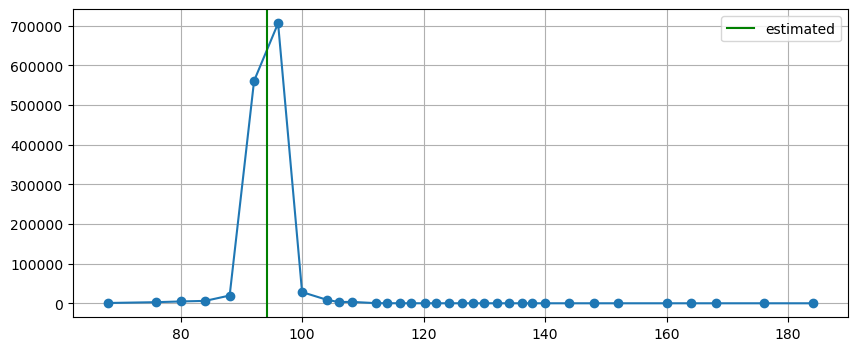

In [49]:
source_estimates = source_estimates_df
event_id = "T1_N2_Refraction1m_T1_N2_E00046"

row = source_estimates[source_estimates["event_id"] == event_id]
display(row)

st = load_nodal_mseed_for_event(event_id)
est = estimate_source_x_from_gather(event_id, st, component="Z")
metric = est["metric"].sort_values("receiver_x_m")

display(metric.sort_values("energy_hp25", ascending=False).head(10))

plt.figure(figsize=(10,4))
plt.plot(metric["receiver_x_m"], metric["energy_hp25"], "o-")
plt.axvline(est["estimated_source_x_m"], color="green", label="estimated")
plt.grid(True)
plt.legend()
plt.show()

## 9. Summarize match quality and estimate Geode clock offset

In [50]:

if len(match_candidates_df):
    best_by_nodal = match_candidates_df.sort_values('score').groupby('nodal_event_id', as_index=False).first()
    display(best_by_nodal[['nodal_event_id','geode_event_id','geode_file_no','geode_source_x_m','estimated_source_x_m','time_residual_s','source_x_residual_m','score']].head(30))

    plt.figure(figsize=(8,4))
    plt.hist(best_by_nodal['time_residual_s'].dropna(), bins=30)
    plt.xlabel('Time residual: nodal - corrected Geode time (s)')
    plt.ylabel('Count')
    plt.title('Best candidate time residuals')
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8,4))
    plt.hist(best_by_nodal['source_x_residual_m'].dropna(), bins=30)
    plt.xlabel('Source x residual: nodal estimate - Geode metadata (m)')
    plt.ylabel('Count')
    plt.title('Best candidate source-position residuals')
    plt.grid(True, alpha=0.3)
    plt.show()

    first_by_geode = best_by_nodal.sort_values('time_residual_s').groupby('geode_event_id', as_index=False).first()
    first_by_geode = first_by_geode.sort_values('geode_file_no')
    display(first_by_geode[['geode_event_id','geode_file_no','geode_source_x_m','nodal_event_id','time_residual_s','source_x_residual_m']].head(50))
    print('Median first-event residual after current clock correction:', np.nanmedian(first_by_geode['time_residual_s']))
    print('Suggested extra clock adjustment to make first residual median ~0 s:', np.nanmedian(first_by_geode['time_residual_s']))
else:
    print('No match candidates to summarize.')


No match candidates to summarize.


## 10. Plot one matched event in detail

In [51]:

if len(match_candidates_df):
    best_by_nodal = match_candidates_df.sort_values('score').groupby('nodal_event_id', as_index=False).first()
    REVIEW_EVENT_ID = best_by_nodal.iloc[0]['nodal_event_id']
else:
    REVIEW_EVENT_ID = needs_match.iloc[0]['event_id'] if len(needs_match) else None
REVIEW_EVENT_ID


'T1_N2_Refraction1m_T1_N2_E00001'

No candidate rows for this event.


,station,channel,receiver_x_m,energy_raw,energy_hp25,rms_raw,rms_hp25,peak_abs_raw,peak_abs_hp25
3,08405,DPZ,84.05,1.821313e+06,1.729016e+06,60.293915,58.746319,561.998842,567.518280
2,08003,DPZ,80.03,9.201640e+04,9.013313e+04,13.552323,13.412921,117.109188,114.610696
4,08808,DPZ,88.08,3.315345e+04,3.032560e+04,8.134774,7.780112,78.925255,77.111221
5,09210,DPZ,92.10,3.174253e+04,2.967122e+04,7.959796,7.695712,51.539548,50.328916
1,07600,DPZ,76.00,2.365740e+04,2.252186e+04,6.871707,6.704761,72.483588,68.787555
6,09605,DPZ,96.05,6.331974e+03,5.229272e+03,3.555091,3.230738,24.763996,25.674647
7,10000,DPZ,100.00,2.769779e+03,2.280821e+03,2.351277,2.133668,16.585662,16.440985
0,06809,DPZ,68.09,1.646452e+03,1.254101e+03,1.812824,1.582149,10.676776,10.722897
8,10408,DPZ,104.08,7.315800e+02,6.129964e+02,1.208404,1.106140,7.966032,7.520738
10,10814,DPZ,108.14,4.807537e+02,3.684237e+02,0.979586,0.857541,5.230994,4.889429


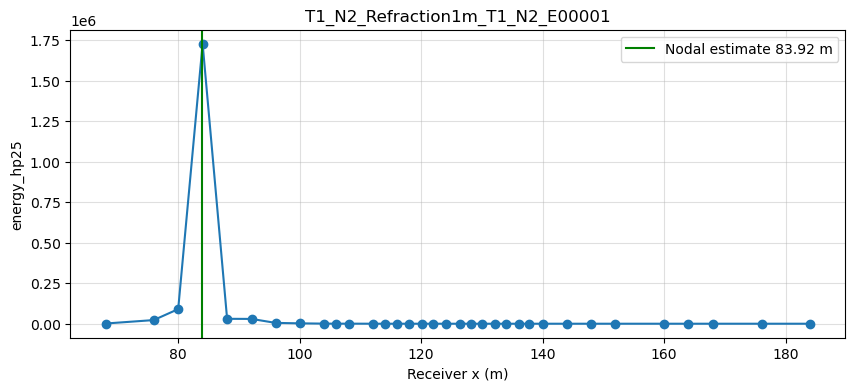

In [52]:

def inspect_match_event(event_id):
    st, path = load_nodal_gather(event_id)
    est = estimate_source_x_from_gather(event_id, st, component=SOURCE_COMPONENT)
    metric = est['metric']
    energy_col = est.get('energy_col', f'energy_hp{int(SOURCE_HP_FREQ_HZ)}')
    cand = pd.DataFrame()
    if len(match_candidates_df):
        cand = match_candidates_df[match_candidates_df['nodal_event_id'].astype(str) == str(event_id)].sort_values('score').copy()
    geode_x = np.nan
    if len(cand):
        geode_x = pd.to_numeric(cand.iloc[0]['geode_source_x_m'], errors='coerce')
        print('Best candidate:')
        display(cand.head(10))
    else:
        print('No candidate rows for this event.')
    display(metric.sort_values(energy_col, ascending=False).head(10))
    plot_energy_position(metric, event_id=event_id, estimated_source_x_m=est['estimated_source_x_m'], geode_source_x_m=geode_x, energy_col=energy_col)
    if HAVE_SEGY_TOOLS:
        try:
            fig = plot_wiggle_gather_from_stream(
                st.select(channel='*Z'), sort_by='receiver_x', fallback_receiver_spacing_m=4.0,
                fallback_first_receiver_x_m=0.0, title=str(event_id), tmin=PLOT_TMIN_S,
                tmax=PLOT_TMAX_S, scale=0.8, clip_percentile=99, normalize=True)
            ax = fig.axes[0]
            if np.isfinite(est['estimated_source_x_m']):
                ax.axvline(est['estimated_source_x_m'], color='green', linestyle='-', label='Nodal source estimate')
            if np.isfinite(geode_x):
                ax.axvline(geode_x, color='red', linestyle='--', label='Geode metadata source')
            ax.legend(); plt.show()
        except Exception as e:
            print('Wiggle plot failed:', e)
    return est, cand

if REVIEW_EVENT_ID is not None:
    est_review, cand_review = inspect_match_event(REVIEW_EVENT_ID)


## 11. Off-end / near-end shot test

In [53]:

if len(geode_subset):
    receiver_x_min = pd.to_numeric(receiver_geometry.get('receiver_x_m'), errors='coerce').min() if not receiver_geometry.empty else np.nan
    receiver_x_max = pd.to_numeric(receiver_geometry.get('receiver_x_m'), errors='coerce').max() if not receiver_geometry.empty else np.nan
    gtest = geode_subset.copy()
    if np.isfinite(receiver_x_min) and np.isfinite(receiver_x_max):
        gtest['distance_to_nearest_end_m'] = np.minimum(abs(gtest['source_x_m'] - receiver_x_min), abs(gtest['source_x_m'] - receiver_x_max))
        offend_row = gtest.sort_values('distance_to_nearest_end_m').iloc[0]
    else:
        offend_row = gtest.sort_values('source_x_m').iloc[0]
    print('Selected off-end / near-end Geode row:')
    display(offend_row.to_frame().T)
    gt = offend_row['geode_time_corrected_dt']
    subset = nodal_events[(nodal_events['timewindow_label'].astype(str) == TARGET_TIMEWINDOW_LABEL) & (nodal_events['event_time_dt'].notna())].copy()
    subset['dt_s'] = (subset['event_time_dt'] - gt).dt.total_seconds()
    subset = subset[(subset['dt_s'] >= -TIME_BEFORE_S) & (subset['dt_s'] <= TIME_AFTER_S)].copy()
    print('Nodal detections in stack window:', len(subset))
    display(subset[['event_id','event_time_dt','dt_s']].head(20))
else:
    print('No Geode subset available.')


Selected off-end / near-end Geode row:


,event_id,instrument_system,line,transect,survey,survey_type,shot_no,file_no,source_x_m,source_type,n_blows,n_shots,operator,plate_type,shot_time_local,shot_time_utc,receiver_first_m,receiver_last_m,receiver_spacing_m,nominal_shot_spacing_m,geode_read_ok,geode_read_format,geode_n_traces,geode_sampling_rate_hz,geode_duration_s_first_trace,geode_file_path,geode_folder,geode_match_status,geode_match_note,source_page,confidence,review_status,comment,metadata_source_sheet,extra_json,run_id,network,location,timewindow_label,geometry_id,detection_time_utc,on_time_utc,off_time_utc,duration_s,matched_metadata_event_id,metadata_match_status,metadata_match_time_error_s,detection_n_seed_ids,detection_n_stations,detection_seed_ids,detection_stations,snr_rms,n_receivers_extracted,n_traces_extracted,status,notes,shot_time_dt,detection_time_dt,event_time_dt,geode_time_corrected_dt,distance_to_nearest_end_m
45,GEODE_T1_1M_REFRACTION_F3046,geode,T1,T1,T1_1m_refraction,refraction,46.0,3046.0,162.5,hammer,9.0,NaN,Andy,metal,2026-05-18T18:38:33,2026-05-18T22:38:33+00:00,87.0,158.0,1.0,2.0,1.0,SEG2,72.0,8000.0,0.399875,/Volumes/tachyon/LBSSP_DATA/GEODE_DATA/LBSSP_0...,LBSSP_051826,matched,single file_no match,LBSS17,High,OK,single file_no match,T1_1m_Refraction,"{""geode_folder_date"": ""2026-05-18T00:00:00"", ""...",run_20260612T200044Z_bdd2ebb7,None,None,None,None,None,None,None,NaN,None,None,NaN,NaN,None,None,None,NaN,NaN,NaN,None,None,2026-05-18 22:38:33+00:00,NaT,2026-05-18 22:38:33+00:00,2026-05-18 22:38:21.500000+00:00,53.5


Nodal detections in stack window: 0


,event_id,event_time_dt,dt_s


## 12. Save candidates and estimates

In [54]:

source_estimates_path = OUTPUT_DIR / f'source_estimates_{TARGET_TIMEWINDOW_LABEL}.csv'
match_candidates_path = OUTPUT_DIR / f'match_candidates_{TARGET_TIMEWINDOW_LABEL}.csv'
source_estimates_df.to_csv(source_estimates_path, index=False)
match_candidates_df.to_csv(match_candidates_path, index=False)
print('Wrote:', source_estimates_path)
print('Wrote:', match_candidates_path)

if len(match_candidates_df):
    conn.execute('''
        CREATE TABLE IF NOT EXISTS nodal_geode_match_candidates (
            nodal_event_id TEXT,
            nodal_time_utc TEXT,
            nodal_line TEXT,
            nodal_timewindow_label TEXT,
            estimated_source_x_m REAL,
            geode_event_id TEXT,
            geode_survey TEXT,
            geode_file_no TEXT,
            geode_line TEXT,
            geode_time_utc TEXT,
            geode_time_corrected_utc TEXT,
            geode_source_x_m REAL,
            source_type TEXT,
            operator TEXT,
            plate_type TEXT,
            n_blows REAL,
            time_residual_s REAL,
            source_x_residual_m REAL,
            score REAL
        )
    ''')
    ids = tuple(match_candidates_df['nodal_event_id'].unique())
    if len(ids) == 1:
        conn.execute('DELETE FROM nodal_geode_match_candidates WHERE nodal_event_id = ?', (ids[0],))
    else:
        placeholders = ','.join(['?'] * len(ids))
        conn.execute(f'DELETE FROM nodal_geode_match_candidates WHERE nodal_event_id IN ({placeholders})', ids)
    conn.commit()
    match_candidates_df.to_sql('nodal_geode_match_candidates', conn, if_exists='append', index=False)
    conn.commit()
    print('Wrote match candidates to SQLite.')
else:
    print('No match candidates to write to SQLite.')


Wrote: /Volumes/tachyon/LBSSP_DATA/catalog/match_review/source_estimates_T1_N2_Refraction1m.csv
Wrote: /Volumes/tachyon/LBSSP_DATA/catalog/match_review/match_candidates_T1_N2_Refraction1m.csv
No match candidates to write to SQLite.


## 13. Manual accepted-match table

In [55]:

ACCEPTED_MATCHES = {
    # Example:
    # 'T1_N2_Refraction1m_T1_N2_E00046': {
    #     'geode_event_id': 'GEODE_T1_1M_REFRACTION_F3011',
    #     'accepted': True,
    #     'notes': 'Time and HP25 source estimate agree.'
    # },
}

def write_reviewed_matches(conn, accepted_matches, candidates_df, reviewer='Glenn'):
    rows = []
    now = datetime.now(timezone.utc).isoformat()
    for nodal_id, item in accepted_matches.items():
        geode_id = item.get('geode_event_id')
        accepted = int(bool(item.get('accepted', True)))
        notes = item.get('notes', '')
        cand = candidates_df[(candidates_df['nodal_event_id'].astype(str) == str(nodal_id)) & (candidates_df['geode_event_id'].astype(str) == str(geode_id))].copy()
        r = cand.iloc[0].to_dict() if len(cand) else {'nodal_event_id': nodal_id, 'geode_event_id': geode_id}
        r.update({'accepted': accepted, 'reviewer': reviewer, 'review_time_utc': now, 'review_notes': notes})
        rows.append(r)
    out = pd.DataFrame(rows)
    if out.empty:
        print('No reviewed matches to write.')
        return out
    out.to_sql('nodal_geode_matches_reviewed', conn, if_exists='append', index=False)
    conn.commit()
    print('Reviewed matches written:', len(out))
    return out

reviewed_df = write_reviewed_matches(conn, ACCEPTED_MATCHES, match_candidates_df)


No reviewed matches to write.


## 14. Summary

In [56]:

summary = {
    'target_timewindow_label': TARGET_TIMEWINDOW_LABEL,
    'target_geode_survey': TARGET_GEODE_SURVEY,
    'geode_clock_ahead_s': GEODE_CLOCK_AHEAD_S,
    'n_nodal_events_total': len(nodal_events),
    'n_geode_events_total': len(geode_events),
    'n_review_subset': len(needs_match),
    'n_source_estimates': len(source_estimates_df),
    'n_match_candidates': len(match_candidates_df),
}
print(json.dumps(summary, indent=2))
with open(OUTPUT_DIR / f'match_review_summary_{TARGET_TIMEWINDOW_LABEL}.json', 'w') as f:
    json.dump(summary, f, indent=2)


{
  "target_timewindow_label": "T1_N2_Refraction1m",
  "target_geode_survey": "T1_1m_refraction",
  "geode_clock_ahead_s": 11.5,
  "n_nodal_events_total": 3425,
  "n_geode_events_total": 327,
  "n_review_subset": 100,
  "n_source_estimates": 100,
  "n_match_candidates": 0
}
